# The Adding Problem

## Introduction

In this series of exercises, we will probe the nature of RNNs, LSTMs, and GRUs using the adding problem. In this problem, we have a $2\times n$ matrix, where the first row is filled with random numbers between 0 and 1. The second row contains all zeros, except for at two positions. The solution to the problem is the sum of the two random numbers in the first row that are at the same index as the two ones in the second row. We can cast this as a signal processing problem where we observe a random signal and define a mask over it. The adding problem is visualised in the figure below.

We will now train an RNN, LSTM, and GRU-based model on the task of predicting the sum given a sequence and mask pair and the evaluate the model by giving it test pairs and let it predict the sum of the two non-masked (one in the second row) values in the first row.
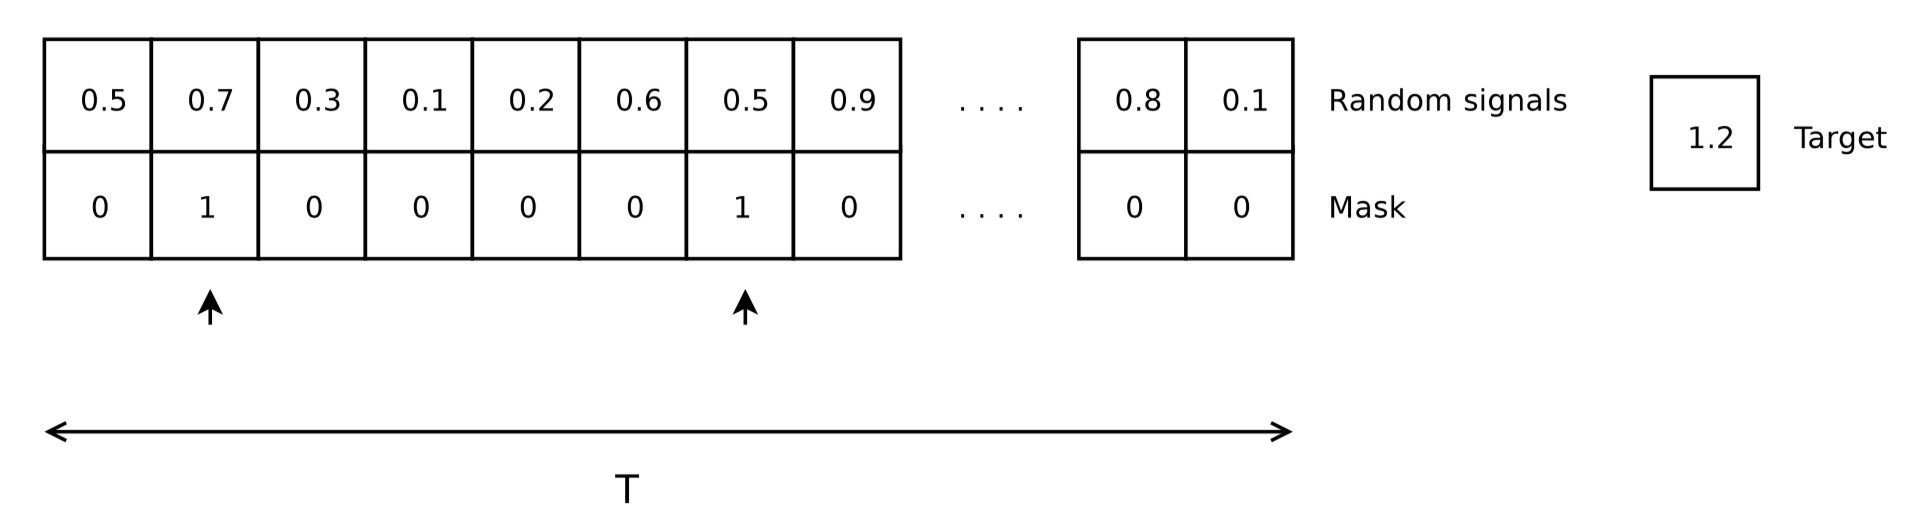
(Q. V. Le, N. Jaitly, and G. E. Hinton, “A Simple Way to Initialize Recurrent Networks of Rectified Linear Units”, arXiv.org, vol. cs.NE. 04-Apr-2015.)

## Code

### Setup
Here, we import everything we need. Note that to run this notebook successfully, you must install `torch`, `numpy`, `matplotlib`, and `livelossplot`. We also seed both torch and numpy to make the code reproducible.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader, TensorDataset
# Uncomment below if needed
# !pip install livelossplot
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

torch.manual_seed(42)
np.random.seed(42)

### Hyperparameters/Settings
Given our problem setup/data, changing the set sizes, the hidden dimension, or the batch size doesn't do too much interesting. What is interesting on the other hand, is the sequence length.

In [ ]:
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
SEQ_LEN    = 40
N_TRAIN    = 4000
N_TEST     = 1000
BATCH_SIZE = 128
EPOCHS     = 50
HIDDEN     = 64
LR         = 5e-3

### The Dataset
Here we create the data set according to the figure in the introduction. We then wrap it in a `TensorDataset` and a `DataLoader` to make it easy to use during training. Read the code and the comments carefully to understand what is going on if it isn't clear from the introduction.

In [ ]:
def create_adding_dataset(n: int, seq_len: int):
    # We create two numpy arrays, one for the data x and one for the labels y, and
    # initialise them so each element is 0.
    x = np.zeros((n, seq_len, 2), dtype=np.float32)
    y = np.zeros((n, 1),          dtype=np.float32)

    # We fill the first row in x with random numbers, two of them will be the numbers
    # to be summed. We do this for all samples at the same time (-> broadcasting).
    x[:, :, 0] = np.random.uniform(0, 1, (n, seq_len))

    # We create n samples
    for i in range(n):
        # The first number to sum has an index in the first half of the sequence,
        # while the second one has an index in the second half of the sequence.
        pos1 = np.random.randint(0, seq_len // 2)
        pos2 = np.random.randint(seq_len // 2, seq_len)

        # For the two positions we want to sum, we set the respective element in
        # the second row to 1.0.
        x[i, pos1, 1] = 1.0
        x[i, pos2, 1] = 1.0

        # The label we want to predict is the sum of the two values stored at the
        # above defined positions in the second row.
        y[i, 0] = x[i, pos1, 0] + x[i, pos2, 0]

    return torch.from_numpy(x), torch.from_numpy(y)


X_train, y_train = create_adding_dataset(N_TRAIN, SEQ_LEN)
X_test,  y_test  = create_adding_dataset(N_TEST,  SEQ_LEN)

train_loader = DataLoader(TensorDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE)

### The Model(s)
We create a single class that takes the RNN type (RNN, LSTM, or GRU) as an argument to create the respective neural network model. The head (last layer) is just a simple linear layer.

In [ ]:
class SequenceRegressor(nn.Module):
    def __init__(self, rnn_type: str, input_size=2, hidden_size=HIDDEN):
        super().__init__()
        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[rnn_type]
        self.rnn  = rnn_cls(input_size, hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, hidden = self.rnn(x)
        # LSTM returns hidden + cell, others only hidden
        h = hidden[0] if isinstance(hidden, tuple) else hidden
        return self.head(h[-1])  # last layer, all batches

In [ ]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    plotlosses: PlotLosses,
    n_epochs: int = EPOCHS,
    lr: float = 1e-3,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
) -> dict:
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {"train_loss": [], "test_loss": []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(X_batch)

        train_loss /= len(train_loader.dataset)

        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                test_loss += criterion(model(X_batch), y_batch).item() * len(X_batch)

        test_loss /= len(test_loader.dataset)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)

        plotlosses.update({"train": train_loss, "test": test_loss})
        plotlosses.send()

    return history

## Excercises

### Exercise 1
Before you run the code below, think about, or discuss with your neighbour, how the three architectures (RNN, LSTM, and GRU) will perform on the adding problem task.

### Exercise 2
Run the three models below and check the results against your assumptions from Exercise 1. What do you observe and how does it relate to the theoretic foundation of the three models?

#### RNN

In [ ]:
plotlosses = PlotLosses(
    groups={"loss": ["train", "test"]}, 
    outputs=[MatplotlibPlot(figsize=(16, 4), max_epoch=EPOCHS)]
)
model = SequenceRegressor("RNN")
rnn_history = train_model(model, train_loader, test_loader, plotlosses)

#### LSTM

In [ ]:
plotlosses = PlotLosses(
    groups={"loss": ["train", "test"]}, 
    outputs=[MatplotlibPlot(figsize=(16, 4), max_epoch=EPOCHS)]
)
model = SequenceRegressor("LSTM")
lstm_history = train_model(model, train_loader, test_loader, plotlosses)

#### GRU

In [ ]:
plotlosses = PlotLosses(
    groups={"loss": ["train", "test"]}, 
    outputs=[MatplotlibPlot(figsize=(16, 4), max_epoch=EPOCHS)]
)
model = SequenceRegressor("GRU")
rnn_gru = train_model(model, train_loader, test_loader, plotlosses)

### Exercise 3
Adjust the sequence length (`SEQ_LEN`, under heading *Hyperparameters/Settings*) and train the models again. What effects do you observe and how do they relate to the nature of the three architectures?